In [9]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

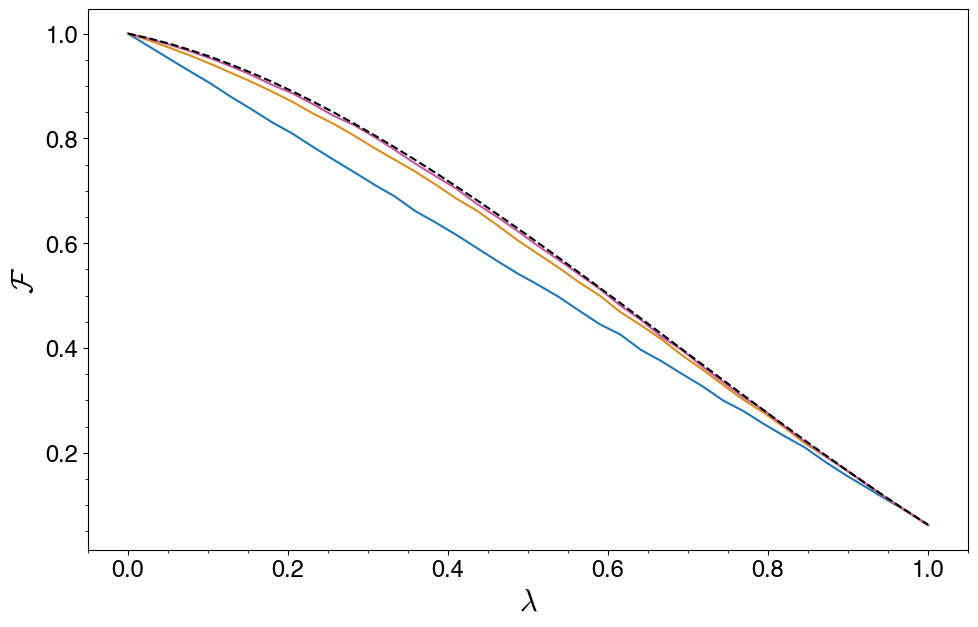

In [10]:
# Set global font settings
mpl.rcParams['font.family'] = 'Helvetica'           # Use Helvetica for main text
mpl.rcParams['mathtext.fontset'] = 'cm'             # Use Computer Modern for math (\mathcal)
mpl.rcParams['font.size'] = 14                      # Increase base font size
mpl.rcParams['axes.labelsize'] = 22                 # Axis label font size
mpl.rcParams['legend.fontsize'] = 18                # Legend font size
mpl.rcParams['xtick.labelsize'] = 17                # Tick label size
mpl.rcParams['ytick.labelsize'] = 17
custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']

# Folder containing the combined CSV files
data_folder = "aer_global_simulation/simulation_k4_shots102400_lam0.0-1.0_s41"
files = glob.glob(os.path.join(data_folder, "nqpa*_combined.csv"))

# Dict to store dataframes keyed by nqpa
data_by_nqpa = {}

# Extract nqpa and read corresponding CSV
for file in files:
    match = re.search(r'nqpa(\d+)_combined\.csv', file)
    if match:
        nqpa = int(match.group(1))
        df = pd.read_csv(file)
        data_by_nqpa[nqpa] = df
    else:
        print(f"Filename does not match expected pattern: {file}")

# Plotting
plt.figure(figsize=(10, 6.5))

label_map = {
    0: 'Unamplified',
    1: r'Amplified $N_{\mathrm{trials}}=1$',
    2: r'Amplified $N_{\mathrm{trials}}=2$'
}

for nqpa, df in sorted(data_by_nqpa.items()):
    color = custom_colors[nqpa % len(custom_colors)]
    y_key = f'QPA_{nqpa}'
    if y_key in df.columns and 'Lambda' in df.columns:
        label = label_map.get(nqpa, f'nqpa={nqpa}')
        plt.plot(df['Lambda'], df[y_key], color=color, label=label)
    else:
        print(f"Missing expected columns in nqpa={nqpa} file")

lambda_vals = df['Lambda']
theory_k4 = (1/128) * (-16 + 15 * lambda_vals) * (-8 + 5 * (lambda_vals - 1) * lambda_vals)
plt.plot(lambda_vals, theory_k4, 'k--', label='Theory')

# Add minor ticks to both axes
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\mathcal{F}$')
# plt.legend(frameon=True, edgecolor='black')
plt.tight_layout()
plt.savefig("aer_global_simulation/Simulation_k=4.pdf", format="pdf")
plt.show()

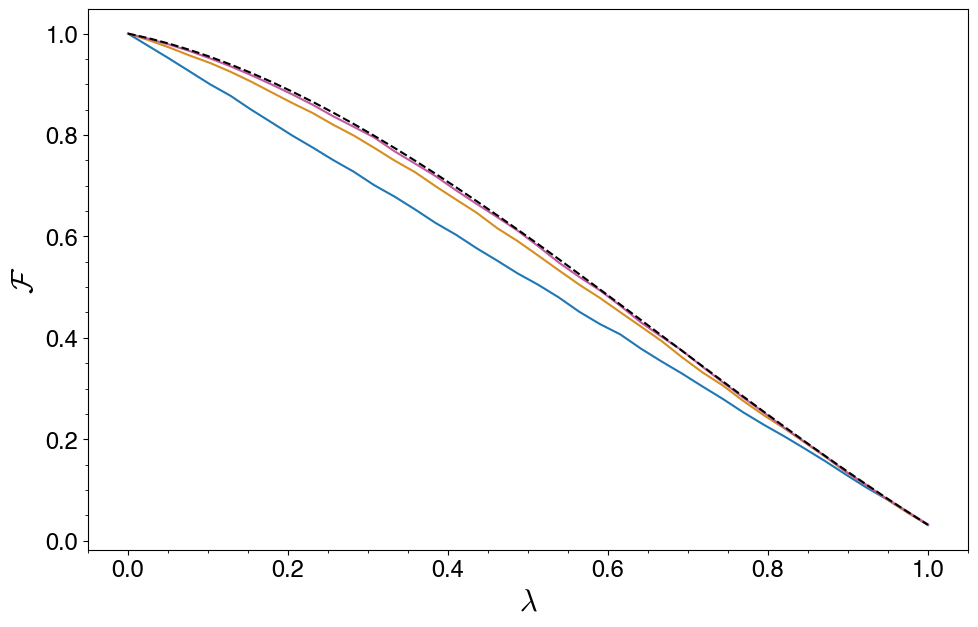

In [11]:
# Set global font settings
mpl.rcParams['font.family'] = 'Helvetica'           # Use Helvetica for main text
mpl.rcParams['mathtext.fontset'] = 'cm'             # Use Computer Modern for math (\mathcal)
mpl.rcParams['font.size'] = 14                      # Increase base font size
mpl.rcParams['axes.labelsize'] = 22                 # Axis label font size
mpl.rcParams['legend.fontsize'] = 18                # Legend font size
mpl.rcParams['xtick.labelsize'] = 17                # Tick label size
mpl.rcParams['ytick.labelsize'] = 17

## Folder containing the combined CSV files
data_folder = "aer_global_simulation/simulation_k5_shots102400_lam0.0-1.0_s41"
files = glob.glob(os.path.join(data_folder, "nqpa*_combined.csv"))

# Dict to store dataframes keyed by nqpa
data_by_nqpa = {}

# Extract nqpa and read corresponding CSV
for file in files:
    match = re.search(r'nqpa(\d+)_combined\.csv', file)
    if match:
        nqpa = int(match.group(1))
        df = pd.read_csv(file)
        data_by_nqpa[nqpa] = df
    else:
        print(f"Filename does not match expected pattern: {file}")

# Plotting
plt.figure(figsize=(10, 6.5))

label_map = {
    0: 'Unamplified',
    1: r'Amplified $N_{\mathrm{trials}}=1$',
    2: r'Amplified $N_{\mathrm{trials}}=2$'
}

for nqpa, df in sorted(data_by_nqpa.items()):
    color = custom_colors[nqpa % len(custom_colors)]
    y_key = f'QPA_{nqpa}'
    if y_key in df.columns and 'Lambda' in df.columns:
        label = label_map.get(nqpa, f'nqpa={nqpa}')
        plt.plot(df['Lambda'], df[y_key], color=color, label=label)
    else:
        print(f"Missing expected columns in nqpa={nqpa} file")

lambda_vals = df['Lambda']
theory_k5 = ((-32 + 31 * lambda_vals) * (-48 + 31 * (lambda_vals - 1) * lambda_vals)) / 1536
plt.plot(lambda_vals, theory_k5, 'k--', label='Theory')

# Add minor ticks to both axes
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\mathcal{F}$')
# plt.legend(frameon=True, edgecolor='black')
plt.tight_layout()
plt.savefig("aer_global_simulation/Simulation_k=5.pdf", format="pdf")
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_915/1094312183.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


<Figure size 1000x600 with 0 Axes>

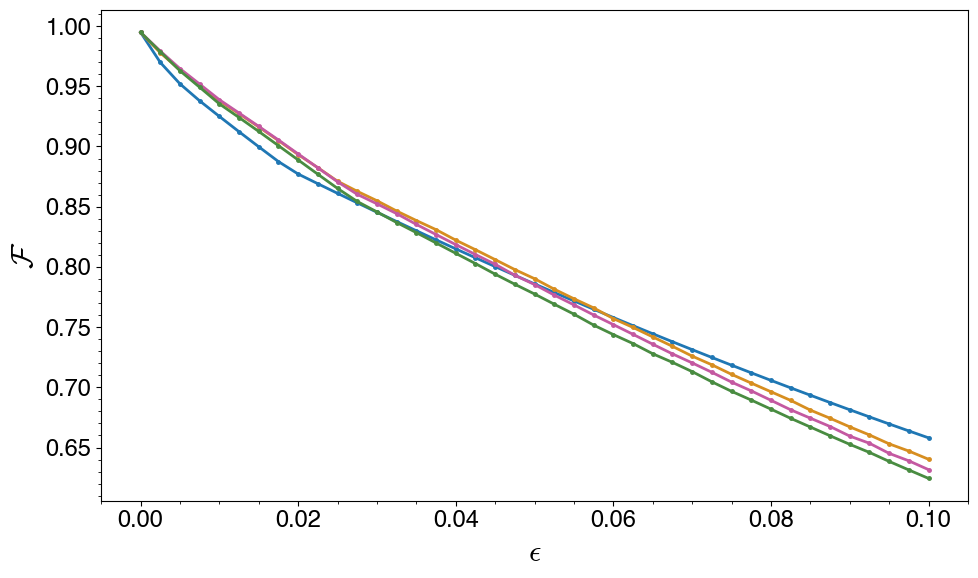

In [12]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k2_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))



# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']

plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', marker='.', markersize=5, color=color, linewidth=2)

ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
# plt.grid(True)
plt.tight_layout()
# plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_915/1251519125.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))
Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1001 ticks ([0.0, ..

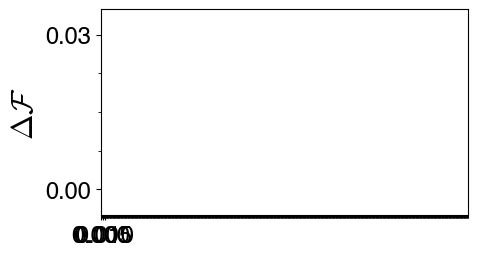

In [13]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import cm

plt.figure(figsize=(5, 2.8))

# Load and group files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k2_shots102400_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign color
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))

# Store base for nqpa=0
base_fid_dict = {}

# Extract fidelity curves
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]
    fidelity_curves[nqpa] = (eps_sorted, fids_sorted)

    if nqpa == 0:
        base_fid_dict = dict(zip(eps_sorted, fids_sorted))

# Plot difference from nqpa=0
for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    if nqpa == 0:
        continue  # Skip baseline

    eps, fids = fidelity_curves[nqpa]
    base_fids = [base_fid_dict.get(e, 0) for e in eps]
    delta_fids = [f - b for f, b in zip(fids, base_fids)]

    plt.plot(eps, delta_fids, color=color, label=f'nqpa={nqpa}',  marker='.', markersize=5, linewidth=2)

# Axes tweaks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks([0.0, 0.005, 0.01])
plt.yticks([-0.03, 0.00, 0.03])
plt.ylabel(r"$\mathcal{\Delta F}$")
plt.ylim(-0.005, 0.035)
# plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('aer_trotter_estimation/inset.pdf', bbox_inches='tight')
# plt.legend()
plt.show()


/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_915/3600066924.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


<Figure size 1000x600 with 0 Axes>

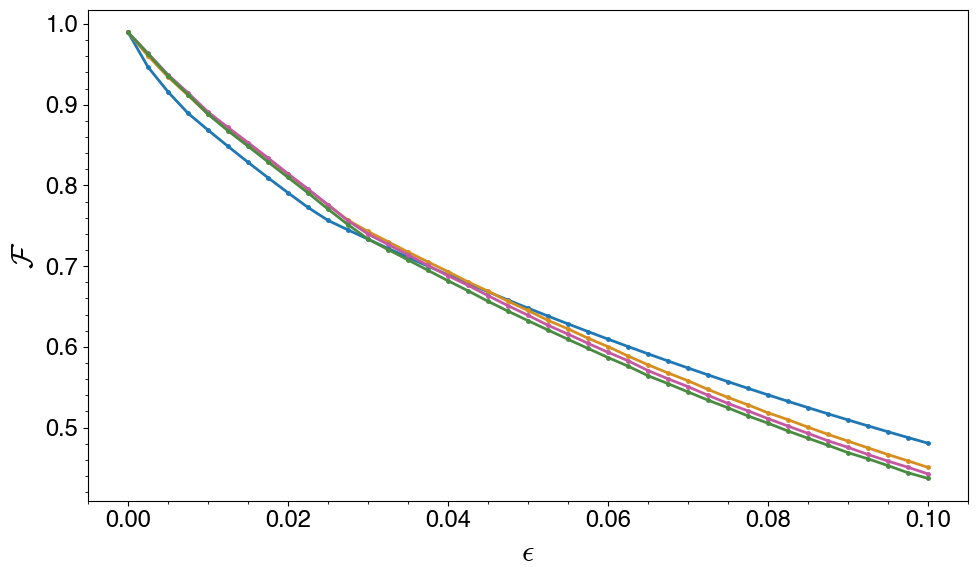

In [14]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))



# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

# for idx, nqpa in enumerate(nqpas):
#     base_color = colormap(idx)
#     norm = mcolors.Normalize(
#         vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
#         vmax=max(ntrot for ntrot, _ in grouped[nqpa])
#     )

#     for ntrot, file in sorted(grouped[nqpa]):
#         df = pd.read_csv(file)
#         # We don’t know the exact column name, so we extract the QPA column:
#         qpa_col = [col for col in df.columns if col.startswith('QPA_')]
#         if qpa_col and 'epsilon' in df.columns:
#             y_key = qpa_col[0]
#             alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
#             color = mcolors.to_rgba(base_color, alpha=alpha)
#             plt.plot(df['epsilon'], df[y_key], marker='o',
#                      color=color,
#                      label=f'nqpa={nqpa}, ntrot={ntrot}')
#         else:
#             print(f"Skipping {file} — missing epsilon or QPA column")

# plt.xlabel('$\epsilon$')
# plt.ylabel('Fidelity')
# plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
# plt.grid(True)
# plt.tight_layout()
# plt.legend(ncol=2, fontsize='small')
# plt.show()


custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']

plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', marker='.', markersize=5, color=color, linewidth=2)

ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
# plt.grid(True)
plt.tight_layout()
# plt.legend()
plt.show()


# # --------------------------------------------
# # Optimal N_trot at each ε for every N_qpa
# # --------------------------------------------
# plt.figure(figsize=(10, 6))

# for idx, nqpa in enumerate(nqpas):
#     eps_to_best_pair = {}  # map ε → (best_fid, best_ntrot)

#     for ntrot, file in grouped[nqpa]:
#         df = pd.read_csv(file)
#         qpa_col = [col for col in df.columns if col.startswith('QPA_')]
#         if not qpa_col or 'epsilon' not in df.columns:
#             continue
#         y_key = qpa_col[0]

#         for eps, fid in zip(df['epsilon'], df[y_key]):
#             best_fid, best_ntrot = eps_to_best_pair.get(eps, (-1, None))
#             if fid > best_fid:
#                 eps_to_best_pair[eps] = (fid, ntrot)

#     # Extract ε values and the chosen N_trot
#     eps_sorted   = sorted(eps_to_best_pair.keys())
#     ntrot_optima = [eps_to_best_pair[eps][1] for eps in eps_sorted]

#     plt.step(eps_sorted, ntrot_optima,
#              where='mid', label=f'nqpa={nqpa}', linewidth=2)

# plt.xlabel('$\\epsilon$')
# plt.ylabel('Optimal $N_{\\mathrm{Trot}}$')
# plt.title('Chosen $N_{\\mathrm{Trot}}$ that Maximizes Fidelity\n'
#           'for Each $N_{\\mathrm{QPA}}$ (102 400 shots, $K=4$)')
# plt.yticks(sorted({ntrot for _, files in grouped.items() for ntrot, _ in files}))
# plt.grid(True, axis='y')
# plt.tight_layout()
# plt.legend()
# plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_31085/288964242.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


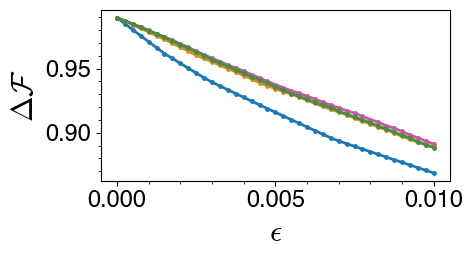

In [ ]:
plt.figure(figsize=(5, 2.8))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))



# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']


for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', marker='.', markersize=5, color=color, linewidth=2)

ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{\Delta F}$')
# plt.grid(True)
plt.tight_layout()
# plt.legend()
plt.show()

<Figure size 1000x600 with 0 Axes>

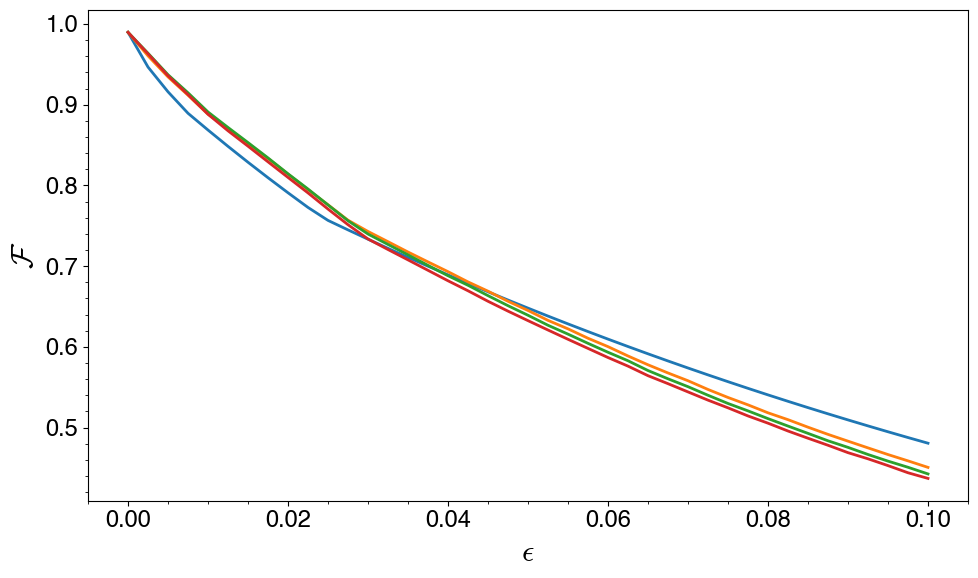

In [ ]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# # Collect data grouped by nqpa
# grouped = {}
# for file in files:
#     match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
#     if match:
#         nqpa = int(match.group(1))
#         ntrot = int(match.group(2))
#         grouped.setdefault(nqpa, []).append((ntrot, file))
#     else:
#         print(f"Skipping {file} — filename pattern not matched")

# # Assign a color per nqpa
# nqpas = sorted(grouped.keys())
# colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

# for idx, nqpa in enumerate(nqpas):
#     base_color = colormap(idx)
#     norm = mcolors.Normalize(
#         vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
#         vmax=max(ntrot for ntrot, _ in grouped[nqpa])
#     )

#     for ntrot, file in sorted(grouped[nqpa]):
#         df = pd.read_csv(file)
#         # We don’t know the exact column name, so we extract the QPA column:
#         qpa_col = [col for col in df.columns if col.startswith('QPA_')]
#         if qpa_col and 'epsilon' in df.columns:
#             y_key = qpa_col[0]
#             alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
#             color = mcolors.to_rgba(base_color, alpha=alpha)
#             plt.plot(df['epsilon'], df[y_key], marker='o',
#                      color=color,
#                      label=f'nqpa={nqpa}, ntrot={ntrot}')
#         else:
#             print(f"Skipping {file} — missing epsilon or QPA column")

# plt.xlabel('$\epsilon$')
# plt.ylabel('Fidelity')
# plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
# plt.grid(True)
# plt.tight_layout()
# plt.legend(ncol=2, fontsize='small')
# plt.show()


plt.figure(figsize=(10, 6))
custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
# plt.title('k=3, 1024000 trials: Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
# plt.grid(True)
plt.tight_layout()
# plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_31085/1294995300.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


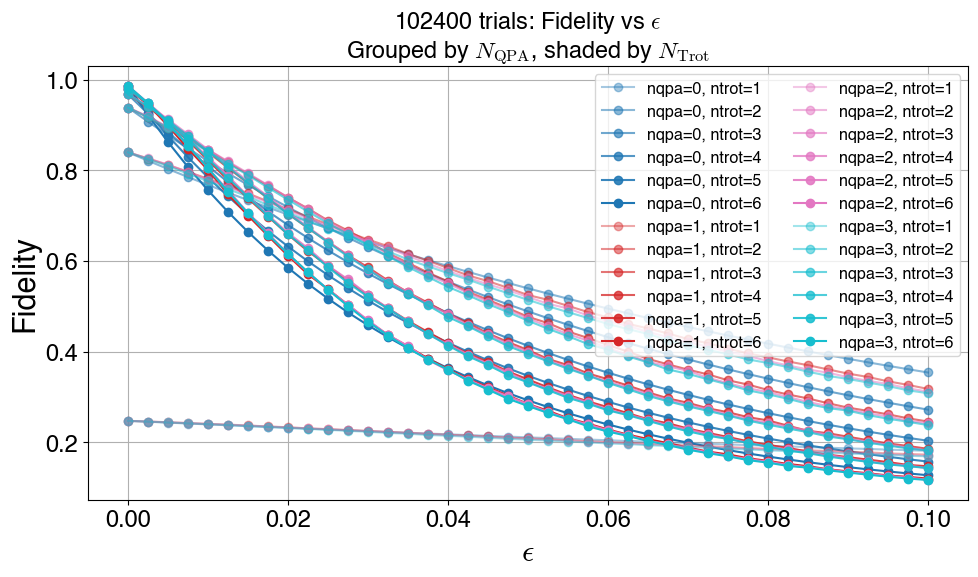

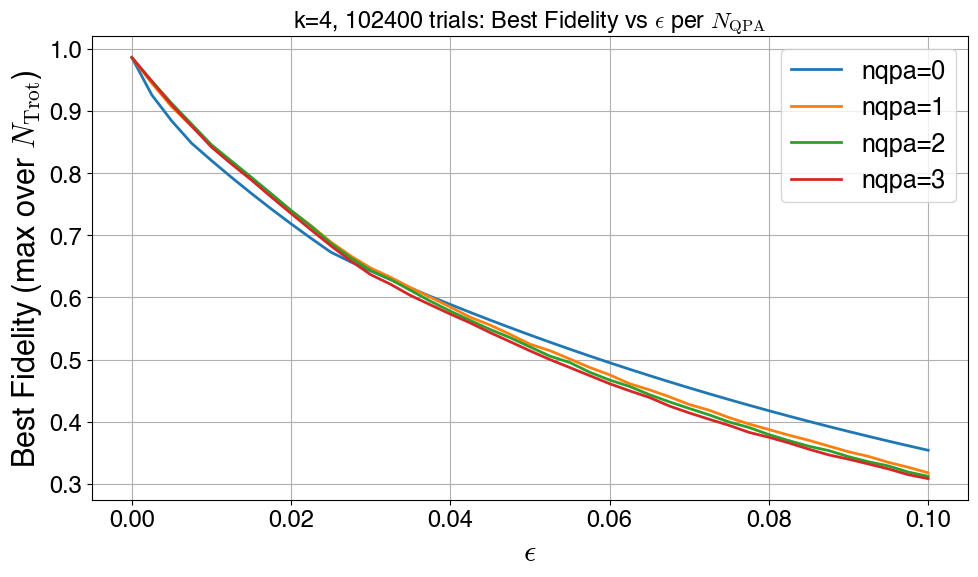

In [5]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    base_color = colormap(idx)
    norm = mcolors.Normalize(
        vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
        vmax=max(ntrot for ntrot, _ in grouped[nqpa])
    )

    for ntrot, file in sorted(grouped[nqpa]):
        df = pd.read_csv(file)
        # We don’t know the exact column name, so we extract the QPA column:
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if qpa_col and 'epsilon' in df.columns:
            y_key = qpa_col[0]
            alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
            color = mcolors.to_rgba(base_color, alpha=alpha)
            plt.plot(df['epsilon'], df[y_key], marker='o',
                     color=color,
                     label=f'nqpa={nqpa}, ntrot={ntrot}')
        else:
            print(f"Skipping {file} — missing epsilon or QPA column")

plt.xlabel('$\epsilon$')
plt.ylabel('Fidelity')
plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
plt.grid(True)
plt.tight_layout()
plt.legend(ncol=2, fontsize='small')
plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('k=4, 102400 trials: Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_31085/1294995300.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


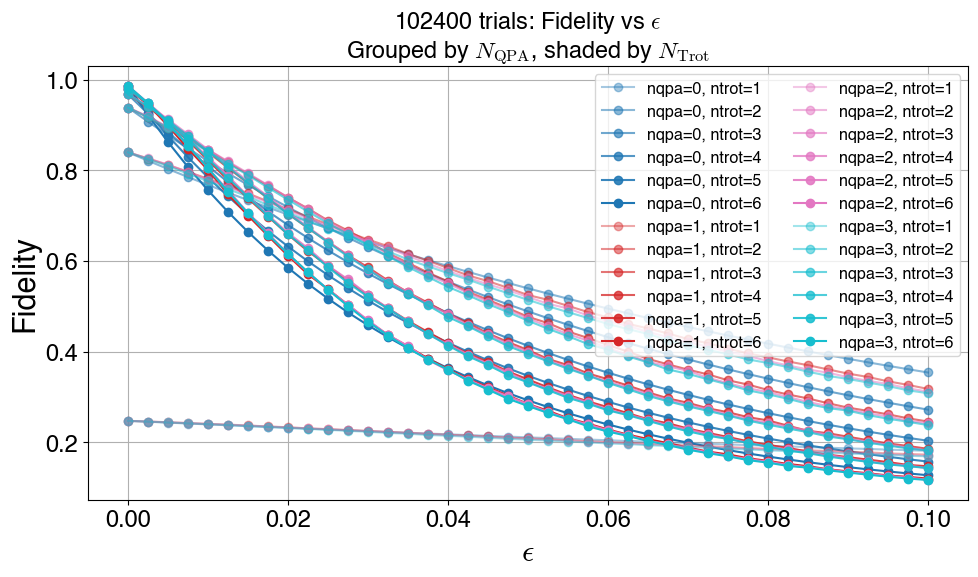

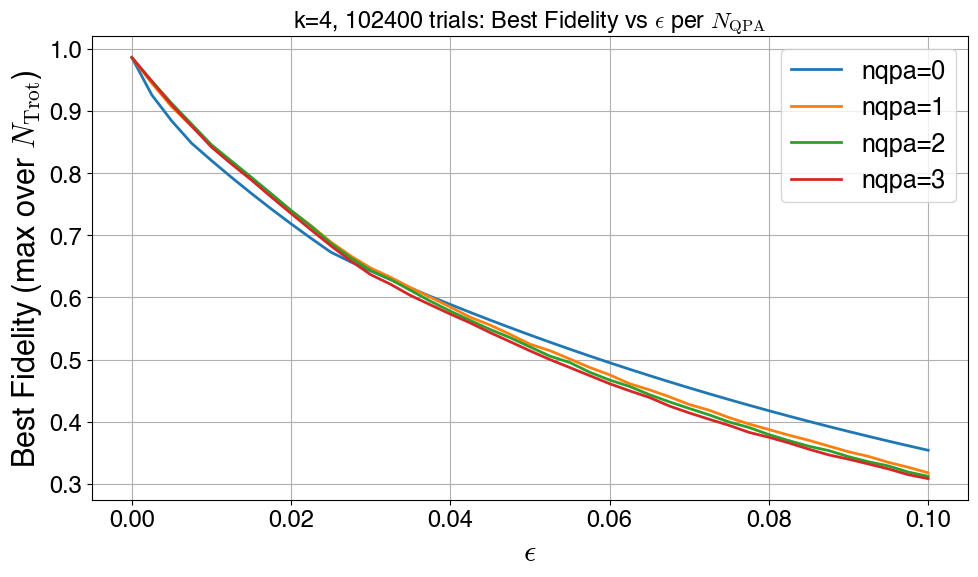

In [6]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    base_color = colormap(idx)
    norm = mcolors.Normalize(
        vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
        vmax=max(ntrot for ntrot, _ in grouped[nqpa])
    )

    for ntrot, file in sorted(grouped[nqpa]):
        df = pd.read_csv(file)
        # We don’t know the exact column name, so we extract the QPA column:
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if qpa_col and 'epsilon' in df.columns:
            y_key = qpa_col[0]
            alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
            color = mcolors.to_rgba(base_color, alpha=alpha)
            plt.plot(df['epsilon'], df[y_key], marker='o',
                     color=color,
                     label=f'nqpa={nqpa}, ntrot={ntrot}')
        else:
            print(f"Skipping {file} — missing epsilon or QPA column")

plt.xlabel('$\epsilon$')
plt.ylabel('Fidelity')
plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
plt.grid(True)
plt.tight_layout()
plt.legend(ncol=2, fontsize='small')
plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('k=4, 102400 trials: Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_31085/1795954994.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


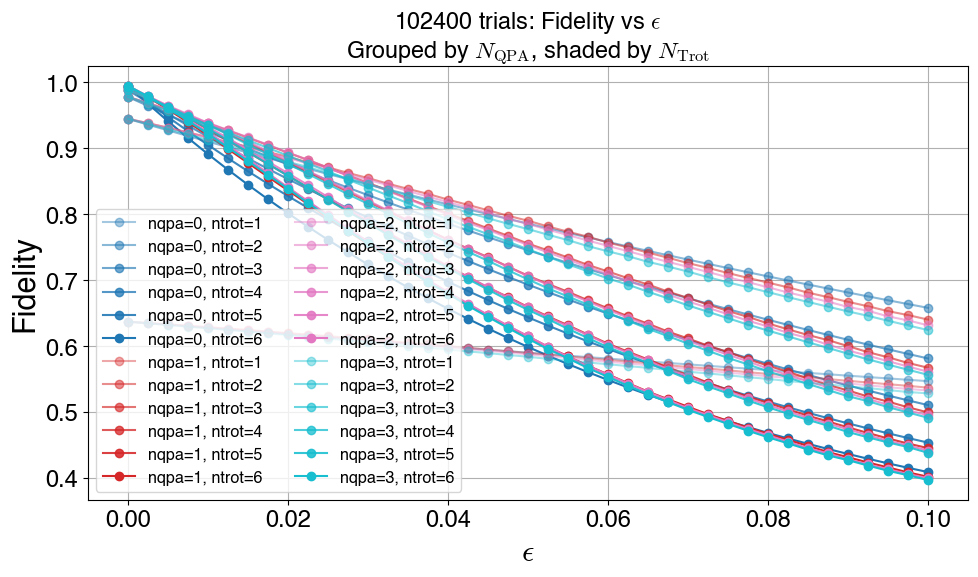

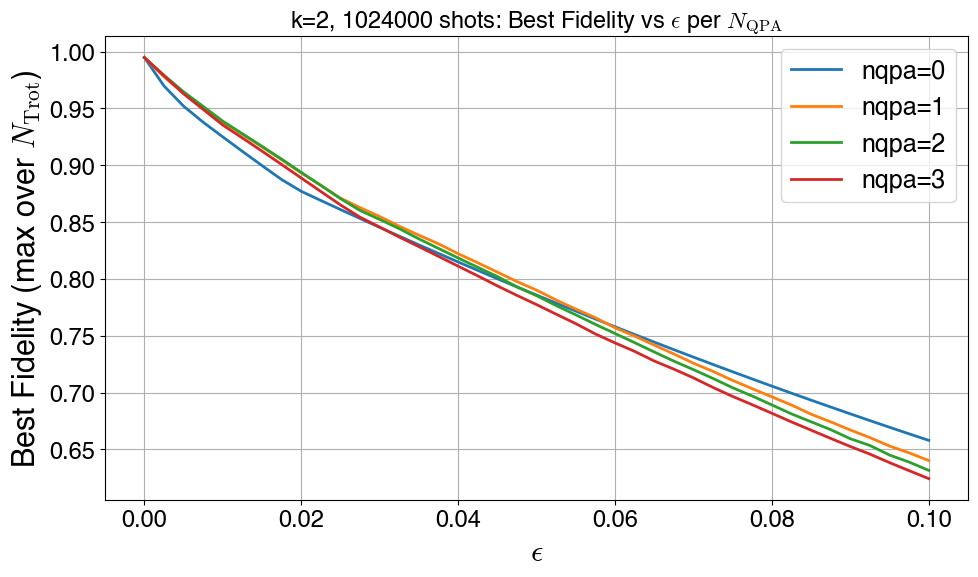

In [7]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k2_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    base_color = colormap(idx)
    norm = mcolors.Normalize(
        vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
        vmax=max(ntrot for ntrot, _ in grouped[nqpa])
    )

    for ntrot, file in sorted(grouped[nqpa]):
        df = pd.read_csv(file)
        # We don’t know the exact column name, so we extract the QPA column:
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if qpa_col and 'epsilon' in df.columns:
            y_key = qpa_col[0]
            alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
            color = mcolors.to_rgba(base_color, alpha=alpha)
            plt.plot(df['epsilon'], df[y_key], marker='o',
                     color=color,
                     label=f'nqpa={nqpa}, ntrot={ntrot}')
        else:
            print(f"Skipping {file} — missing epsilon or QPA column")

plt.xlabel('$\epsilon$')
plt.ylabel('Fidelity')
plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
plt.grid(True)
plt.tight_layout()
plt.legend(ncol=2, fontsize='small')
plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('k=2, 1024000 shots: Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_915/3240226017.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors
/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_915/3240226017.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=2, fontsize='small')


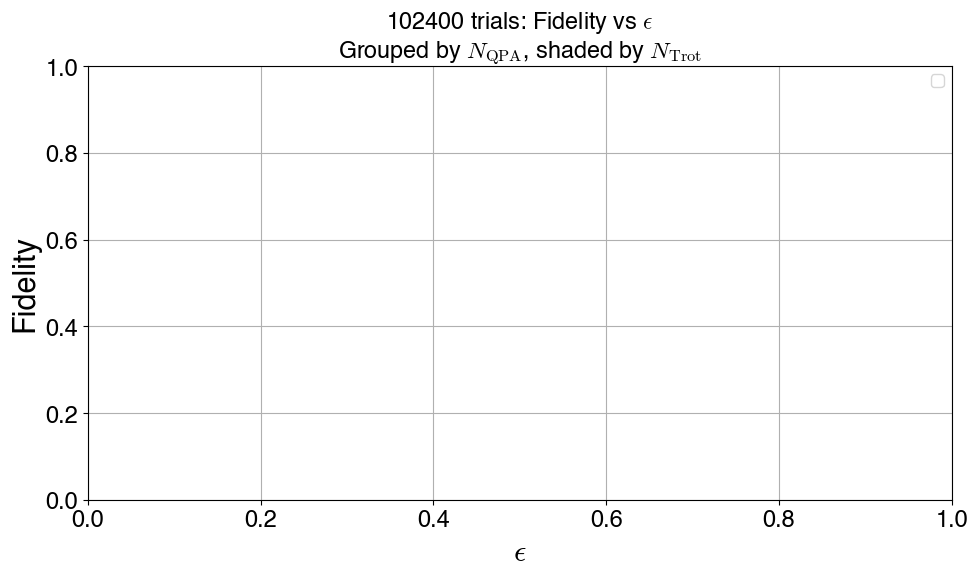

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_915/3240226017.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


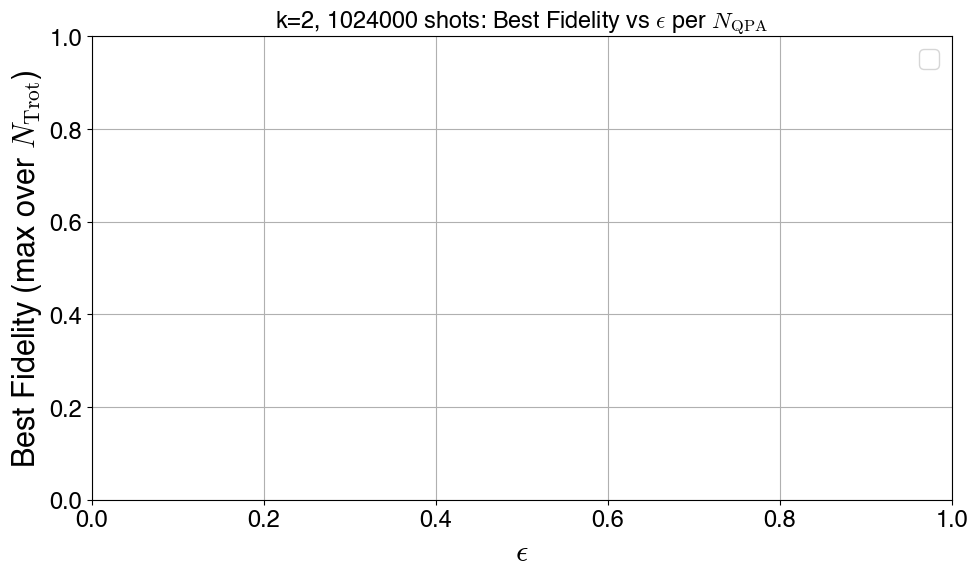

In [15]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("estimation_k2_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

for idx, nqpa in enumerate(nqpas):
    base_color = colormap(idx)
    norm = mcolors.Normalize(
        vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
        vmax=max(ntrot for ntrot, _ in grouped[nqpa])
    )

    for ntrot, file in sorted(grouped[nqpa]):
        df = pd.read_csv(file)
        # We don’t know the exact column name, so we extract the QPA column:
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if qpa_col and 'epsilon' in df.columns:
            y_key = qpa_col[0]
            alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
            color = mcolors.to_rgba(base_color, alpha=alpha)
            plt.plot(df['epsilon'], df[y_key], marker='o',
                     color=color,
                     label=f'nqpa={nqpa}, ntrot={ntrot}')
        else:
            print(f"Skipping {file} — missing epsilon or QPA column")

plt.xlabel('$\epsilon$')
plt.ylabel('Fidelity')
plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
plt.grid(True)
plt.tight_layout()
plt.legend(ncol=2, fontsize='small')
plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('k=2, 1024000 shots: Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

## Rydberg estimation plotting

In [16]:
def calculate_base_fidelity(datafile, exact_state_file):
    """
    Calculate base fidelity from input states and exact state.
    
    Args:
        datafile: Path to the input states data file
        exact_state_file: Path to the exact state file
        
    Returns:
        tuple: (avg_base_fidelity, times_on_s2)
    """
    data = np.load(datafile, allow_pickle=True)
    probs = data["probs"]
    input_states = data["states"]
    
    exact_state_data = np.load(exact_state_file, allow_pickle=True)
    exact_state = exact_state_data["state"]
    
    avg_base_fidelity = 0
    times_on_s2 = []
    
    for i, prob in enumerate(probs):
        input_state = input_states[i]
        q3_input_state = input_state[2]
        base_fidelity = np.abs(np.vdot(q3_input_state, exact_state))**2
        avg_base_fidelity += prob * base_fidelity
        
        if base_fidelity < 0.5:
            times_on_s2.append(prob)
    
    times_on_s2 = np.array(times_on_s2)
    print('Probability outside s1:', times_on_s2.sum())
    print('Probability on s1:', probs.sum() - times_on_s2.sum())
    print('Average base fidelity:', avg_base_fidelity)
    
    return avg_base_fidelity, times_on_s2


import collections
from collections import defaultdict
import csv

def calculate_qpa_fidelity(base_folder, probs, avg_base_fidelity, outfile):
    """
    Calculate QPA fidelity from base folder data.
    
    Args:
        base_folder: Path to the base folder containing QPA results
        probs: Probabilities of input states
        avg_base_fidelity: Average base fidelity for reference
        
    Returns:
        dict: {nqpa: {eps: avg_fidelity}}
    """
    fidelity_qpa = defaultdict(list)  # {nqpa: [(epsilon, fidelity_avg), ...]}
    
    # Loop over all input states
    for i, prob in enumerate(probs):
        input_path = os.path.join(base_folder, f"index{i}")
        if not os.path.exists(input_path):
            print(f"Warning: index{i} folder missing. Nothing on {input_path}")
            continue

        for nqpa_folder in os.listdir(input_path):
            if not nqpa_folder.startswith("nqpa"):
                continue

            nqpa_val = int(nqpa_folder.replace("nqpa", ""))
            full_nqpa_path = os.path.join(input_path, nqpa_folder)
            cache = set()
            for filename in os.listdir(full_nqpa_path):
                if not filename.endswith(".csv"):
                    continue

                filepath = os.path.join(full_nqpa_path, filename)
                try:
                    with open(filepath, "r") as f:
                        reader = csv.reader(f)
                        header = next(reader)
                        row = next(reader)
                        eps = float(row[0])
                        fid = float(row[1])
                        if eps not in cache:
                            cache.add(eps)
                            fidelity_qpa[nqpa_val].append((eps, fid * prob))  # weighted by prob
                except Exception as e:
                    print(f"Failed reading {filepath}: {e}")

    #process the data that's collected
    final_fidelity_qpa = {}  # {nqpa: {eps: avg_fidelity}}
    for nqpa, entries in fidelity_qpa.items():
        eps_groups = collections.defaultdict(list)
        for eps, fid_weighted in entries:
            eps_groups[eps].append(fid_weighted)
        final_fidelity_qpa[nqpa] = {
            eps: fids[0] for eps, fids in eps_groups.items() #for each epsilon, fid, keep one data point (there are repeated data in the set)
        }
    
    # Plot results
    plt.figure(figsize=(10, 6))
    for nqpa in sorted(final_fidelity_qpa.keys()):
        print('NQPA:', nqpa)
        print('Final fidelity qpa:', final_fidelity_qpa[nqpa])
        eps_list = sorted(final_fidelity_qpa[nqpa].keys())
        fidelities = [final_fidelity_qpa[nqpa][eps] for eps in eps_list]
        plt.plot(eps_list, fidelities, label=f"QPA_{nqpa}")

    plt.axhline(y=avg_base_fidelity, linestyle='--', color='gray', label='Base Fidelity')
    plt.xlabel("Epsilon")
    plt.ylabel("Avg Fidelity")
    plt.title("QPA Fidelity vs Noise")
    plt.legend()
    plt.grid(True)
    #Check how many eigenstates we are using
    print("Number of eigenstates used:", len(probs))
    plt.savefig(outfile)
    
    return final_fidelity_qpa

Average base fidelity: 0.8201289239384646
0.8201289239384646


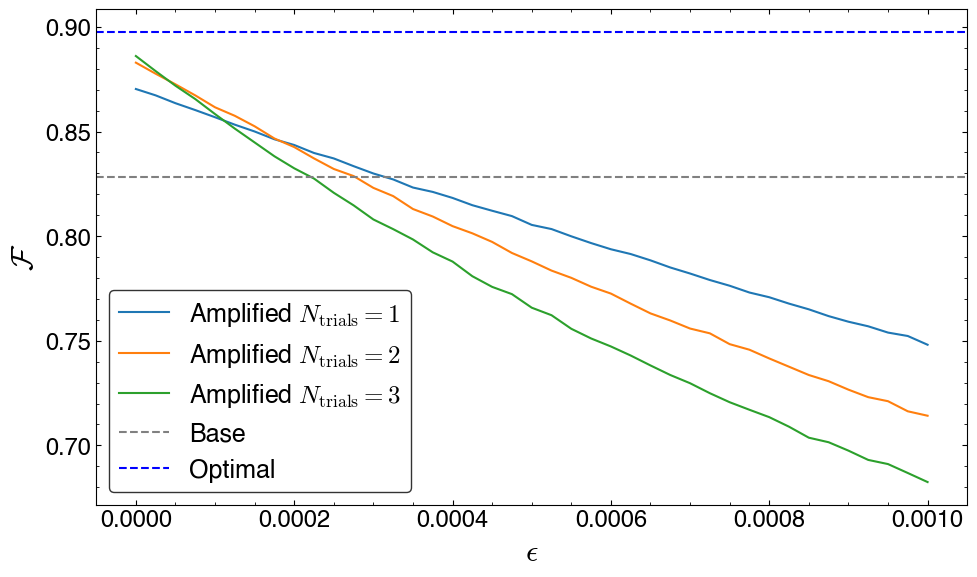

Plot saved to: aer_ryd_estimation/plotting_results/fidelity_125_k4_nshots102400_eps0.0-0.001_s41.pdf


In [10]:
import os
import csv
import glob
import re
from collections import defaultdict

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 17          # Tick labels
mpl.rcParams['ytick.labelsize'] = 17
# ==========================================================================

# === CONFIGURATION ========================================================
nshots      = 102400
k           = 4
eps_steps   = 41
eps_min     = 0.0
eps_max     = 0.001
eigenstates = 5

base_folder = (
    f"aer_ryd_estimation/simulation_outputs/"
    f"ryd_estimation_{eigenstates**3}_eigenstates_k{k}_shots{nshots}"
    f"_eps{eps_min}-{eps_max}_s{eps_steps}"
)
outfile_pdf = (
    f"aer_ryd_estimation/plotting_results/"
    f"fidelity_{eigenstates**3}_k{k}_nshots{nshots}_eps{eps_min}-{eps_max}_s{eps_steps}.pdf"
)

datafile           = "aer_ryd_estimation/all_states_5_eigenstates.npz"
exact_state_file   = "aer_ryd_estimation/exact_state.npz"
# ==========================================================================

# === LOAD PROBABILITIES AND STATES =======================================
data         = np.load(datafile, allow_pickle=True)
probs        = data["probs"]
input_states = data["states"]

exact_state  = np.load(exact_state_file, allow_pickle=True)["state"]
# ==========================================================================

# === COMPUTE BASE FIDELITY ===============================================
avg_base_fidelity = 0.0
for prob, state_tuple in zip(probs, input_states):
    q3_input_state = state_tuple[1]                       # third register state
    fid            = abs(np.vdot(q3_input_state, exact_state))**2
    avg_base_fidelity += prob * fid
print("Average base fidelity:", avg_base_fidelity)
print(avg_base_fidelity)
# ==========================================================================

# === LOAD QPA RESULTS, WEIGHT BY PROBS ====================================
fidelity_qpa = defaultdict(list)

for idx, prob in enumerate(probs):
    input_path = os.path.join(base_folder, f"index{idx}")
    if not os.path.exists(input_path):
        print("Missing:", input_path)
        continue

    for folder in os.listdir(input_path):
        if not folder.startswith("nqpa"):
            continue
        nqpa_val  = int(folder.replace("nqpa", ""))
        csv_path  = os.path.join(input_path, folder, "merged_results.csv")
        if not os.path.exists(csv_path):
            print("Missing CSV:", csv_path)
            continue

        with open(csv_path, newline="") as f:
            reader = csv.reader(f)
            header = next(reader)               # "epsilon, fidelity"
            for eps_str, fid_str in reader:
                eps = float(eps_str)
                fid = float(fid_str)
                fidelity_qpa[nqpa_val].append((eps, fid * prob))
# ==========================================================================

# === GROUP & AGGREGATE ====================================================
final_qpa = {}
for nqpa, entries in fidelity_qpa.items():
    buckets = defaultdict(list)
    for eps, w_fid in entries:
        buckets[eps].append(w_fid)
    final_qpa[nqpa] = {eps: sum(vals) for eps, vals in buckets.items()}
# ==========================================================================

# === PLOTTING =============================================================
plt.figure(figsize=(10, 6))

for nqpa in sorted(final_qpa.keys()):
    eps_list     = sorted(final_qpa[nqpa].keys())
    fidelities   = [final_qpa[nqpa][eps] for eps in eps_list]
    label_prefix = "Unamplified" if nqpa == 0 else f"Amplified $N_{{\\mathrm{{trials}}}}={nqpa}$"
    plt.plot(eps_list, fidelities, label=label_prefix)

plt.axhline(y=0.8284986603752338, linestyle="--", color="gray", label="Base")
plt.axhline(y=0.897822559792652, linestyle="--", color="blue", label="Optimal")

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.tick_params(which="both", direction="in", top=True, right=True)

plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$\mathcal{F}$")
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()

plt.savefig(outfile_pdf)
plt.show()

print("Plot saved to:", outfile_pdf)
